**Student:** Aimen A Ali Etorki

**Student Number: 30095294**

**Year:** Feb 2025 Intake

**Supervisor:** Dr Mabrouka Abuhmida

**MSc Project:** CS4T702_2025/26 Artificial Intelligence 

**Project Title:**  Explainable Hybrid AI Model for Early Detection of Alzheimer’s Disease Using MRI-Derived Hippocampal and Brain Structural Features

# Notebook 3: ADNI MRI Preprocessing

## Objective

Develop and validate the preprocessing pipeline that converts a reconstructed MRI
volume into model-ready 2D coronal slices using one example participant. Notebook 4
then applies the same preprocessing pipeline across the full cohort.

## Preprocessing Approach

The preprocessing pipeline prepares the MRI data for subsequent deep learning and
hybrid modelling while reducing irrelevant image content and redundancy between
neighbouring slices.

The main preprocessing stages are:

**1. Intensity normalisation.** MRI intensities are percentile-clipped and scaled
to a common range while preserving the background as zero. This reduces variation
in raw intensity ranges between acquisitions.

**2. Brain extraction.** A brain mask is applied to reduce non-brain structures
such as skull, scalp and surrounding tissue before slice selection.

**3. Anatomical reorientation.** The reconstructed MRI volume is reoriented to the
coronal plane used for the subsequent 2D analysis.

**4. Informative slice selection.** Brain content is measured across the
reoriented volume, and 20 slices are sampled evenly from the informative
anatomical range. This maintains anatomical coverage while reducing redundancy
between neighbouring slices.

**5. Image resizing.** Selected slices are resized to 224 × 224 pixels to provide
a consistent input size for the deep learning model.

The preprocessing functions are imported from `src/mri_utils.py`, generated in
Notebook 2, ensuring that the same processing logic is used consistently when the
full cohort is prepared in Notebook 4.

> **Prerequisite:** run Notebook 2 first to generate `src/mri_utils.py`.

In [1]:
# ============================================================
# Project Configuration
#
# The project root is identified automatically so that file paths
# remain relative to the project structure rather than depending
# on a specific computer or user directory.
# ============================================================

from pathlib import Path


def find_project_root(marker_folders=("MRI 1.5T & 3T Dataset", "notebooks")):
    """Walk upwards until a folder containing the project markers is found."""

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if any((candidate / m).exists() for m in marker_folders):
            return candidate

    # Use the default project path if the project root is not found
    return Path(r"C:\Users\aimen\Documents\GitHub\MSc-Final-Project")


PROJECT_ROOT = find_project_root()

RAW_DATA = PROJECT_ROOT / "MRI 1.5T & 3T Dataset"
MRI_FOLDER = RAW_DATA / "ADNI"

CSV_FILE = PROJECT_ROOT / "MRI_1.5T___3T_Dataset_7_08_2026.csv"

PROCESSED_DATA = PROJECT_ROOT / "processed"
DATASET_FOLDER = PROJECT_ROOT / "dataset"
FINAL_DATASET_FOLDER = PROJECT_ROOT / "final_dataset"
MODELS_FOLDER = PROJECT_ROOT / "models"
RESULTS_FOLDER = PROJECT_ROOT / "results"
SRC_FOLDER = PROJECT_ROOT / "src"

for folder in [PROCESSED_DATA, DATASET_FOLDER, FINAL_DATASET_FOLDER,
               MODELS_FOLDER, RESULTS_FOLDER, SRC_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["CN", "MCI", "AD"]
RANDOM_SEED = 42

print("PROJECT_ROOT :", PROJECT_ROOT)
print()
print("Path check")
print("-" * 46)
for label, path in [
    ("MRI folder    ", MRI_FOLDER),
    ("Metadata CSV  ", CSV_FILE),
    ("Processed     ", PROCESSED_DATA),
    ("Final dataset ", FINAL_DATASET_FOLDER),
    ("Source module ", SRC_FOLDER),
]:
    status = "OK " if path.exists() else "MISSING"
    print(f"{label}: [{status}] {path}")

PROJECT_ROOT : C:\Users\aimen\Documents\GitHub\MSc-Final-Project

Path check
----------------------------------------------
MRI folder    : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\MRI 1.5T & 3T Dataset\ADNI
Metadata CSV  : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\MRI_1.5T___3T_Dataset_7_08_2026.csv
Processed     : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\processed
Final dataset : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\final_dataset
Source module : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\src


In [2]:
# ============================================================
# Libraries and Shared Pipeline Module
# ============================================================

import sys
import json

import numpy as np
import matplotlib.pyplot as plt

if str(SRC_FOLDER) not in sys.path:
    sys.path.insert(0, str(SRC_FOLDER))

try:
    import mri_utils
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        f"src/mri_utils.py not found in {SRC_FOLDER}. "
        f"Run Notebook 2 first - to generates this module."
    )

import importlib
importlib.reload(mri_utils)

print("mri_utils loaded from:", mri_utils.__file__)
print()
print("Default parameters")
print("-" * 46)
for name in ["LOWER_PERCENTILE", "UPPER_PERCENTILE", "SIGNAL_THRESHOLD",
             "BRAIN_CONTENT_THRESHOLD", "N_SLICES_PER_PARTICIPANT",
             "IMAGE_SIZE"]:
    print(f"  {name:<28}: {getattr(mri_utils, name)}")

PLANE = "coronal"

print()
print(f"Slicing plane : {PLANE}  (axis {mri_utils.PLANE_AXIS[PLANE]})")    

mri_utils loaded from: C:\Users\aimen\Documents\GitHub\MSc-Final-Project\src\mri_utils.py

Default parameters
----------------------------------------------
  LOWER_PERCENTILE            : 1
  UPPER_PERCENTILE            : 99
  SIGNAL_THRESHOLD            : 0.05
  BRAIN_CONTENT_THRESHOLD     : 0.7
  N_SLICES_PER_PARTICIPANT    : 20
  IMAGE_SIZE                  : (224, 224)

Slicing plane : coronal  (axis 2)


## 3.1 Load an Example Participant

The same participant used in Notebook 2 is retained so that the preprocessing
output can be compared directly with the verified reconstruction.

In [4]:
# ============================================================
# Load the MRI Volume
# ============================================================

participant_id = "013_S_0996"

series = mri_utils.find_mri_series(MRI_FOLDER / participant_id)[0]

volume, slices, info = mri_utils.load_mri_volume(series["path"])

print(f"Participant : {participant_id}")
print(f"Sequence    : {series['sequence']}")
print(f"Volume      : {volume.shape}  ({volume.dtype})")
print(f"Intensity   : {volume.min()} to {volume.max()}")
print(f"Voxel (mm)  : {info['slice_spacing']:.2f} x "
      f"{info['row_spacing']:.2f} x {info['column_spacing']:.2f}")

# ---- reorient to the analysis plane ----
# Reorient the reconstructed volume so that the figures below
# show the coronal plane used for subsequent analysis.

volume = mri_utils.reorient(volume, PLANE)

print()
print(f"Reoriented to {PLANE}: {volume.shape}")
print(f"  {volume.shape[0]} slices of "
      f"{volume.shape[1]}x{volume.shape[2]}")

Participant : 013_S_0996
Sequence    : MPRAGE
Volume      : (160, 192, 192)  (uint16)
Intensity   : 0 to 1049
Voxel (mm)  : 1.20 x 1.25 x 1.25

Reoriented to coronal: (192, 192, 160)
  192 slices of 192x160


## 3.2 Intensity Normalisation

MRI intensities have no absolute scale the same tissue can take very different
values on different scanners or sessions. Normalisation is therefore required
before the volumes can be compared or fed to a network.

A percentile clipped approach is used: the 1st and 99th percentiles of non-zero
voxels define the range, values outside are clipped, and the result is scaled to
[0, 1]. Clipping matters because a handful of very bright voxels often vessels or
artefact would otherwise compress all brain tissue into a narrow band at the
bottom of the range.

Non-zero voxels : 5,827,327
Raw range       : 1 to 1049
1st percentile  : 2.0
99th percentile : 551.0

Voxels clipped at the top: 57,439 (0.99% of brain voxels)

Normalised range: 0.000 to 1.000


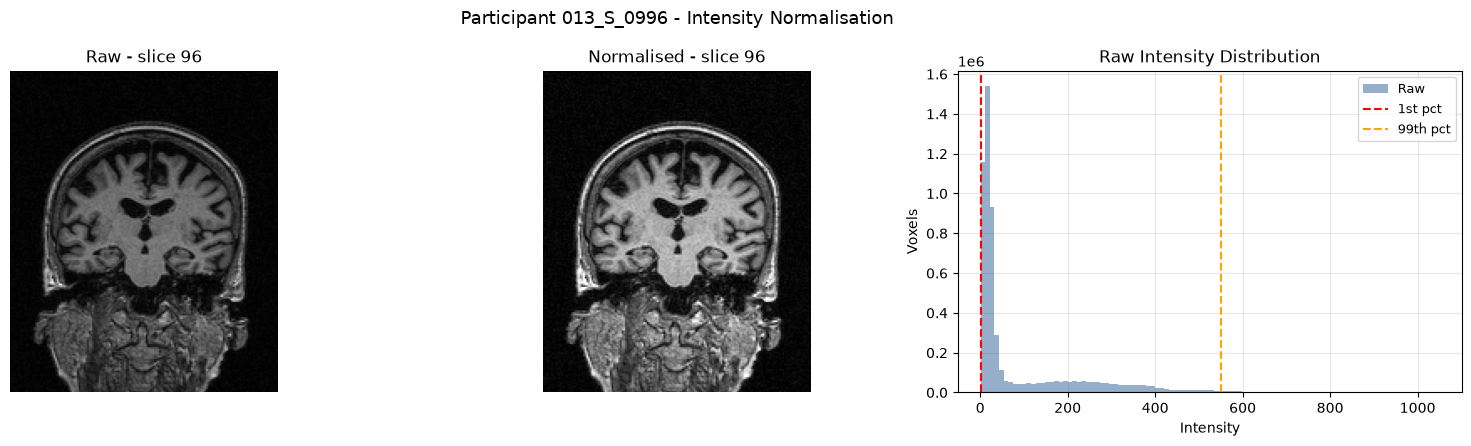

In [6]:
# ============================================================
# Normalise Intensities
# ============================================================

nonzero = volume[volume > 0]

lower_value = np.percentile(nonzero, mri_utils.LOWER_PERCENTILE)
upper_value = np.percentile(nonzero, mri_utils.UPPER_PERCENTILE)

print(f"Non-zero voxels : {nonzero.size:,}")
print(f"Raw range       : {nonzero.min()} to {volume.max()}")
print(f"{mri_utils.LOWER_PERCENTILE}st percentile  : {lower_value:.1f}")
print(f"{mri_utils.UPPER_PERCENTILE}th percentile : {upper_value:.1f}")

clipped_high = (volume > upper_value).sum()
print(f"\nVoxels clipped at the top: {clipped_high:,} "
      f"({clipped_high / nonzero.size:.2%} of brain voxels)")

normalized_volume = mri_utils.normalize_volume(volume)

print(f"\nNormalised range: {normalized_volume.min():.3f} to "
      f"{normalized_volume.max():.3f}")

# ------------------------------------------------------------
# Before / after
# ------------------------------------------------------------

middle = volume.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].imshow(volume[middle], cmap="gray")
axes[0].set_title(f"Raw - slice {middle}")
axes[0].axis("off")

axes[1].imshow(normalized_volume[middle], cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Normalised - slice {middle}")
axes[1].axis("off")

axes[2].hist(nonzero, bins=100, alpha=0.6, label="Raw", color="#4E79A7")
axes[2].axvline(lower_value, color="red", ls="--", label="1st pct")
axes[2].axvline(upper_value, color="orange", ls="--", label="99th pct")
axes[2].set_title("Raw Intensity Distribution")
axes[2].set_xlabel("Intensity")
axes[2].set_ylabel("Voxels")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)
axes[2].set_axisbelow(True)

plt.suptitle(f"Participant {participant_id} - Intensity Normalisation",
             fontsize=13)
plt.tight_layout()
plt.show()

## 3.3 Brain Extraction

Brain extraction is applied to reduce non-brain structures before the MRI slices
are used for subsequent analysis. On T1-weighted MRI, structures such as the skull,
scalp and surrounding soft tissue can contain substantial signal and may introduce
features that are not directly related to brain anatomy.

The method used here is morphological:

1. Threshold the normalised volume to identify foreground tissue
2. **Erode** the binary mask to reduce connections between brain and surrounding tissue
3. Retain the **largest connected component** as the estimated brain region
4. **Dilate** the retained component to restore its approximate extent
5. Fill interior holes in the resulting mask

The resulting mask is then applied to the normalised MRI volume so that voxels
outside the estimated brain region are set to zero.

This is an approximate brain-extraction method rather than a dedicated
skull-stripping algorithm. Dedicated tools such as HD-BET, SynthStrip or FSL BET
may provide more accurate anatomical segmentation, particularly around complex
boundary regions. This limitation should therefore be considered when interpreting
the subsequent model and explainability results.

In [7]:
# ============================================================
# Brain Extraction Assessment
#
# Morphological brain extraction is evaluated before deciding
# whether the resulting mask should be used in the preprocessing
# pipeline. The mask is assessed here but is not applied to the
# analysis volume when SKULL_STRIP is False.
# ============================================================

SKULL_STRIP = False          # must match the setting in Notebook 4

# ---- compute the mask for assessment ----
brain_mask = mri_utils.extract_brain_mask(normalized_volume)
masked_volume = mri_utils.apply_brain_mask(normalized_volume, brain_mask)

mask_fraction = brain_mask.mean()

signal_before = (normalized_volume > mri_utils.SIGNAL_THRESHOLD).sum()
signal_masked = (masked_volume > mri_utils.SIGNAL_THRESHOLD).sum()

mask_retention = signal_masked / signal_before

# ---- decide what actually goes forward ----
if SKULL_STRIP:
    brain_volume = masked_volume
    retained = mask_retention
else:
    brain_volume = normalized_volume
    retained = 1.0

print("Brain extraction assessment")
print("-" * 52)
print(f"  Mask covers               : {mask_fraction:.1%} of the volume")
print(f"  Signal voxels before      : {signal_before:,}")
print(f"  Signal voxels if masked   : {signal_masked:,}")
print(f"  Would retain              : {mask_retention:.1%}")
print(f"  Would remove              : {1 - mask_retention:.1%}")

print()
print(f"  SKULL_STRIP               : {SKULL_STRIP}")
print(f"  Applied to analysis volume: "
      f"{'yes - masked' if SKULL_STRIP else 'NO - whole head retained'}")

# ------------------------------------------------------------
# Assessment
# ------------------------------------------------------------

print()

if mask_retention < 0.40:
    print("ASSESSMENT: the mask removes more than 60% of signal voxels")
    print("on this scan, indicating substantial loss of image content.")
elif mask_retention > 0.95:
    print("ASSESSMENT: the mask removes very little signal on this scan,")
    print("suggesting limited separation of brain and surrounding tissue.")
else:
    print("ASSESSMENT: the mask retains an intermediate proportion of")
    print("signal voxels on this scan. Visual inspection of the mask is")
    print("required to assess its anatomical quality.")

if not SKULL_STRIP:
    print()
    print("Brain extraction is not applied to the analysis volume.")
    print("The subsequent preprocessing therefore uses the normalised")
    print("whole-head MRI.")

Brain extraction assessment
----------------------------------------------------
  Mask covers               : 15.8% of the volume
  Signal voxels before      : 2,365,793
  Signal voxels if masked   : 932,947
  Would retain              : 39.4%
  Would remove              : 60.6%

  SKULL_STRIP               : False
  Applied to analysis volume: NO - whole head retained

ASSESSMENT: the mask removes more than 60% of signal voxels
on this scan, indicating substantial loss of image content.

Brain extraction is not applied to the analysis volume.
The subsequent preprocessing therefore uses the normalised
whole-head MRI.


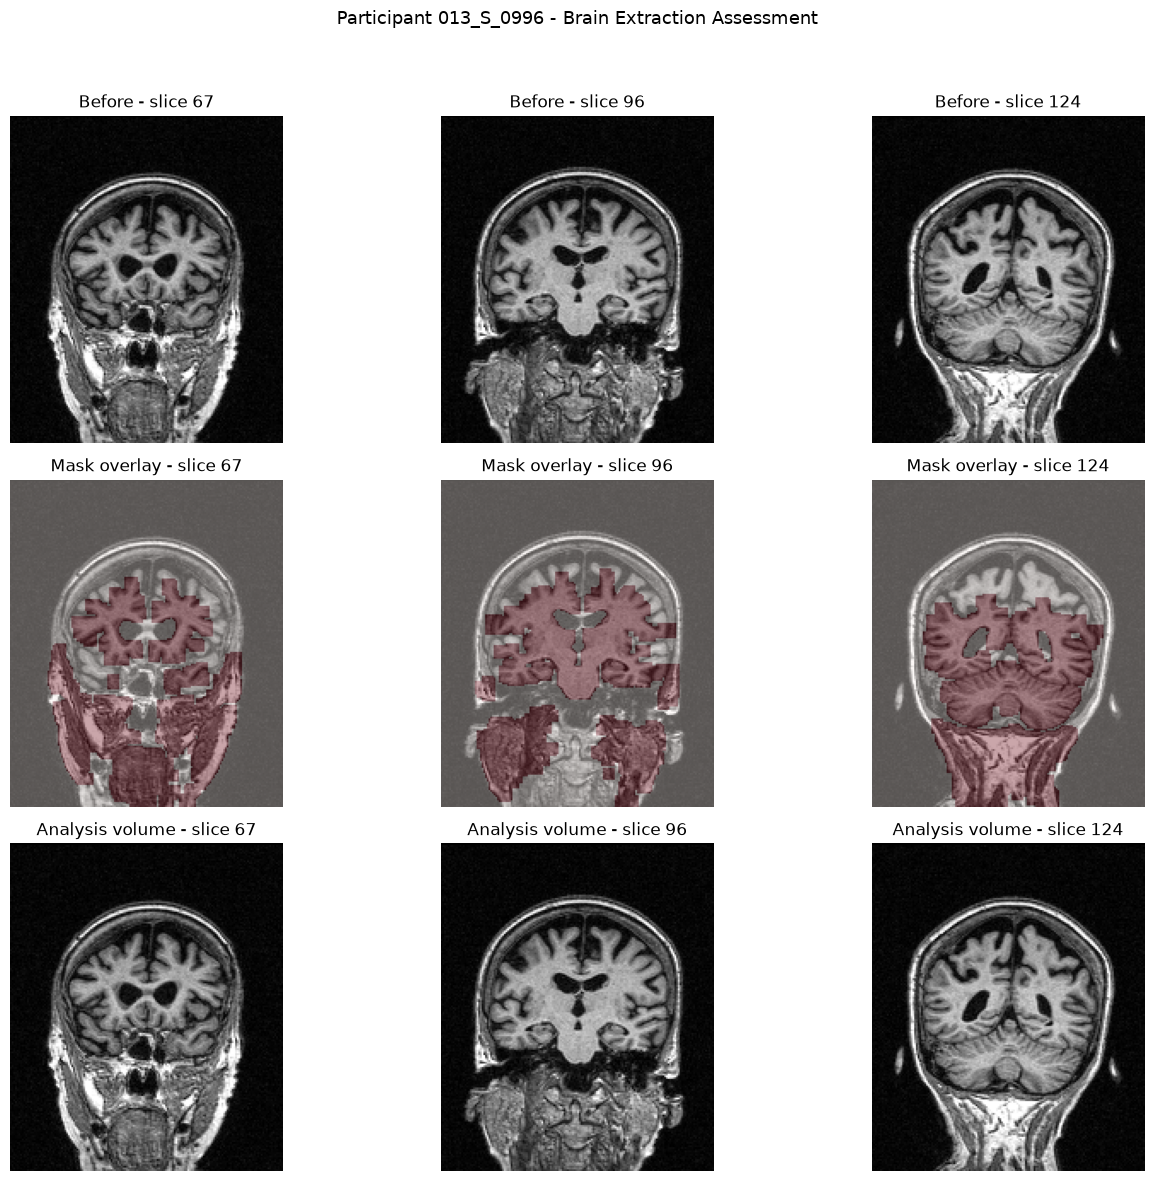

Inspect the mask overlay to assess whether the estimated brain
region retains cortical tissue while reducing surrounding
non-brain structures.
Brain extraction remains disabled, so the normalised whole-head
volume is used for the subsequent preprocessing stages.


In [8]:
# ============================================================
# Visualise the Effect of Brain Extraction
# ============================================================

show_indices = [
    int(volume.shape[0] * 0.35),
    int(volume.shape[0] * 0.50),
    int(volume.shape[0] * 0.65),
]

fig, axes = plt.subplots(3, len(show_indices), figsize=(14, 12))

for column, idx in enumerate(show_indices):

    # ---- before ----
    axes[0, column].imshow(normalized_volume[idx], cmap="gray",
                           vmin=0, vmax=1)
    axes[0, column].set_title(f"Before - slice {idx}")
    axes[0, column].axis("off")

    # ---- mask ----
    axes[1, column].imshow(normalized_volume[idx], cmap="gray",
                           vmin=0, vmax=1)
    axes[1, column].imshow(brain_mask[idx], cmap="Reds", alpha=0.35)
    axes[1, column].set_title(f"Mask overlay - slice {idx}")
    axes[1, column].axis("off")

    # ---- after ----
    axes[2, column].imshow(brain_volume[idx], cmap="gray", vmin=0, vmax=1)
    axes[2, column].set_title(f"Analysis volume - slice {idx}")
    axes[2, column].axis("off")

plt.suptitle(
    f"Participant {participant_id} - Brain Extraction Assessment",
    fontsize=13,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Inspect the mask overlay to assess whether the estimated brain")
print("region retains cortical tissue while reducing surrounding")
print("non-brain structures.")

if not SKULL_STRIP:
    print("Brain extraction remains disabled, so the normalised whole-head")
    print("volume is used for the subsequent preprocessing stages.")


## 3.4 Brain-Content Profile and Slice Selection

The brain-content profile measures the percentage of signal-carrying pixels in
each coronal slice and is used to identify the informative anatomical region of
the MRI volume. Slices toward the outer regions of the volume contain less useful
anatomical information and a greater proportion of background.

Slices are considered informative when their brain-content value reaches a defined
proportion of the maximum content observed within the volume. Rather than retaining
all slices within this range, a fixed number of slices is sampled evenly across
the informative region.

For this pipeline, 20 coronal slices are selected per participant. This preserves
anatomical coverage across the informative region while reducing redundancy between
neighbouring slices and ensuring that each participant contributes the same number
of images to the dataset.

In [9]:
# ============================================================
# Brain-Content Profile
# ============================================================

brain_content = mri_utils.calculate_brain_content(brain_volume)

print(f"Slices analysed : {len(brain_content)}")
print(f"Content range   : {brain_content.min():.2f}% to "
      f"{brain_content.max():.2f}%")

threshold_value = brain_content.max() * mri_utils.BRAIN_CONTENT_THRESHOLD

print(f"Selection cut   : {threshold_value:.2f}% "
      f"({mri_utils.BRAIN_CONTENT_THRESHOLD:.0%} of peak)")

Slices analysed : 192
Content range   : 0.00% to 59.39%
Selection cut   : 41.57% (70% of peak)


Slice selection
  Slices above threshold : 107 (indices 41-147)
  Selected slices        :  20 (indices 41-147)

  Gap between selected slices: 5-6 indices

The selected slices are distributed evenly across the informative anatomical range.


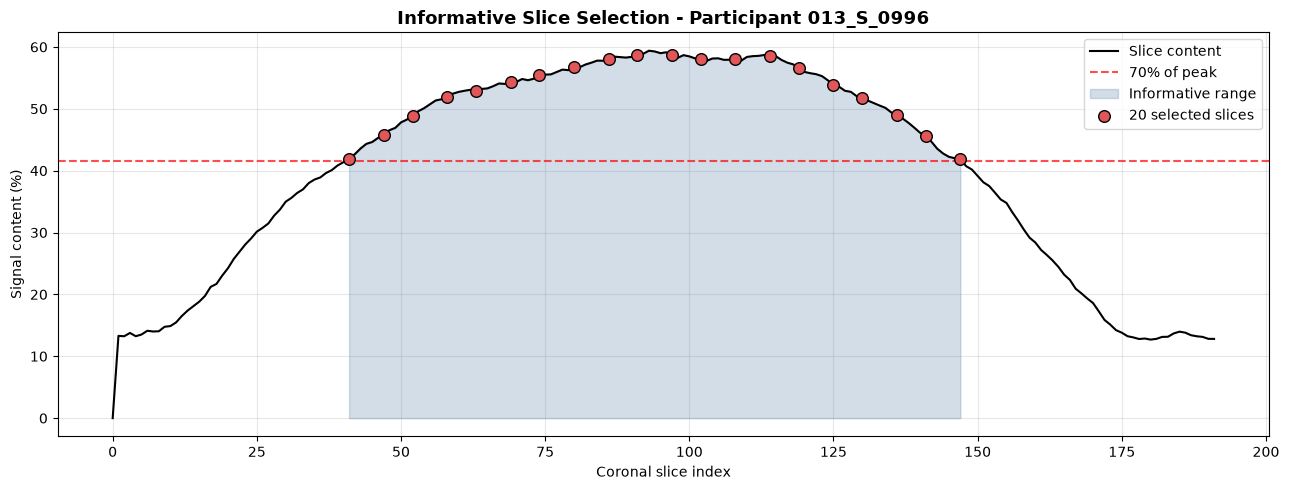

In [10]:
# ============================================================
# Informative Slice Selection
# ============================================================

# Slices meeting the content threshold
threshold_indices = np.where(
    brain_content >= threshold_value
)[0]

# Select a fixed number of slices evenly across the informative range
selected_indices = mri_utils.select_informative_slices(
    brain_content,
    n_slices=mri_utils.N_SLICES_PER_PARTICIPANT,
)

print("Slice selection")
print("=" * 52)

print(
    f"  Slices above threshold : {len(threshold_indices):>3} "
    f"(indices {threshold_indices.min()}-{threshold_indices.max()})"
)

print(
    f"  Selected slices        : {len(selected_indices):>3} "
    f"(indices {selected_indices.min()}-{selected_indices.max()})"
)

if len(selected_indices) > 1:
    spacing = np.diff(selected_indices)

    print(
        f"\n  Gap between selected slices: "
        f"{spacing.min()}-{spacing.max()} indices"
    )

print()
print(
    "The selected slices are distributed evenly across the "
    "informative anatomical range."
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    brain_content,
    color="black",
    lw=1.5,
    label="Slice content",
)

ax.axhline(
    threshold_value,
    color="red",
    ls="--",
    alpha=0.7,
    label=f"{mri_utils.BRAIN_CONTENT_THRESHOLD:.0%} of peak",
)

ax.fill_between(
    range(len(brain_content)),
    0,
    brain_content,
    where=brain_content >= threshold_value,
    color="#4E79A7",
    alpha=0.25,
    label="Informative range",
)

ax.scatter(
    selected_indices,
    brain_content[selected_indices],
    color="#E15759",
    s=70,
    zorder=5,
    edgecolor="black",
    label=f"{len(selected_indices)} selected slices",
)

ax.set_xlabel("Coronal slice index")
ax.set_ylabel("Signal content (%)")

ax.set_title(
    f"Informative Slice Selection - Participant {participant_id}",
    fontsize=13,
    fontweight="bold",
)

ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

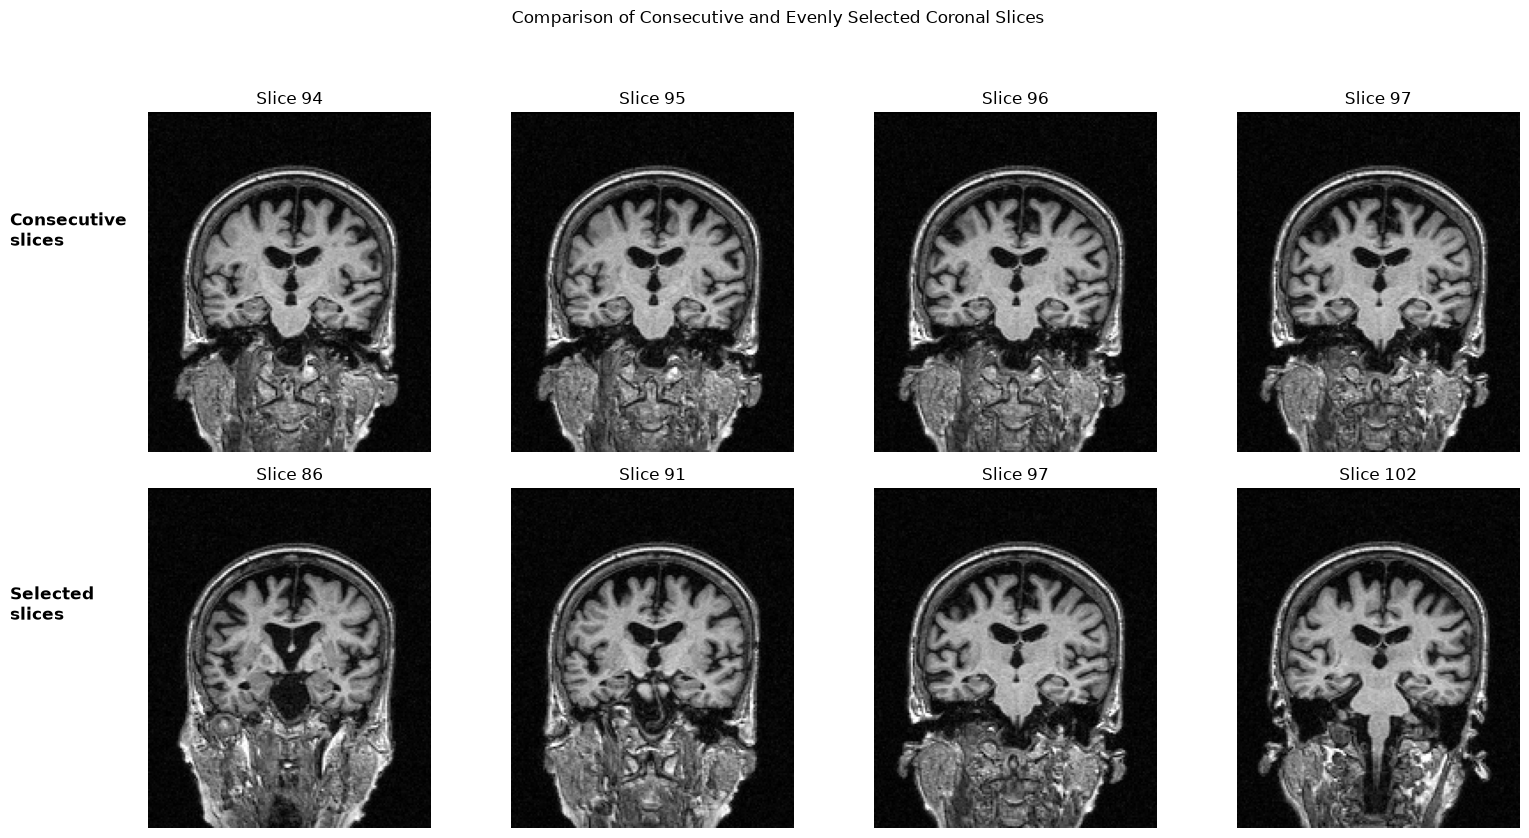

Mean correlation between adjacent images
--------------------------------------------------
  Consecutive slices : 0.9427
  Selected slices    : 0.7509

Higher correlation indicates greater visual similarity between 
neighbouring slices. Evenly spaced selection is used to reduce 
redundancy while maintaining anatomical coverage.


In [13]:
# ============================================================
# Assess Redundancy Between Neighbouring and Selected Slices
# ============================================================

middle_position = len(threshold_indices) // 2

consecutive = threshold_indices[
    middle_position:middle_position + 4
]

sampled = selected_indices[
    len(selected_indices) // 2 - 2:
    len(selected_indices) // 2 + 2
]


fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8.5)
)


# ------------------------------------------------------------
# Consecutive slices
# ------------------------------------------------------------

for column, idx in enumerate(consecutive):

    axes[0, column].imshow(
        brain_volume[idx],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[0, column].set_title(
        f"Slice {idx}"
    )

    axes[0, column].axis("off")


# ------------------------------------------------------------
# Evenly selected slices
# ------------------------------------------------------------

for column, idx in enumerate(sampled):

    axes[1, column].imshow(
        brain_volume[idx],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[1, column].set_title(
        f"Slice {idx}"
    )

    axes[1, column].axis("off")


fig.text(
    0.02,
    0.72,
    "Consecutive\nslices",
    fontsize=12,
    fontweight="bold",
    va="center",
)

fig.text(
    0.02,
    0.28,
    "Selected\nslices",
    fontsize=12,
    fontweight="bold",
    va="center",
)


plt.suptitle(
    "Comparison of Consecutive and Evenly Selected Coronal Slices",
    fontsize=12,
)

plt.tight_layout(
    rect=[0.07, 0, 1, 0.94]
)

plt.show()


# ============================================================
# Quantify Slice Similarity
# ============================================================

def correlation(a, b):
    return float(
        np.corrcoef(
            a.ravel(),
            b.ravel(),
        )[0, 1]
    )


consecutive_correlations = [
    correlation(
        brain_volume[consecutive[i]],
        brain_volume[consecutive[i + 1]],
    )
    for i in range(len(consecutive) - 1)
]


sampled_correlations = [
    correlation(
        brain_volume[sampled[i]],
        brain_volume[sampled[i + 1]],
    )
    for i in range(len(sampled) - 1)
]


print("Mean correlation between adjacent images")
print("-" * 50)

print(
    f"  Consecutive slices : "
    f"{np.mean(consecutive_correlations):.4f}"
)

print(
    f"  Selected slices    : "
    f"{np.mean(sampled_correlations):.4f}"
)

print()
print("Higher correlation indicates greater visual similarity between ")
print("neighbouring slices. Evenly spaced selection is used to reduce ")
print("redundancy while maintaining anatomical coverage.")


## 3.5 Resize and Save

Selected slices are resized to 224 × 224 pixels to provide a consistent input
size for the deep learning model. The preprocessing parameters are saved alongside
the arrays so that the exact configuration used to generate the dataset is
recorded and reproducible.

Output shape    : (20, 224, 224)
Intensity range : 0.000 to 1.000
Memory          : 4.0 MB per participant
Estimated total : 1.65 GB for 411 participants


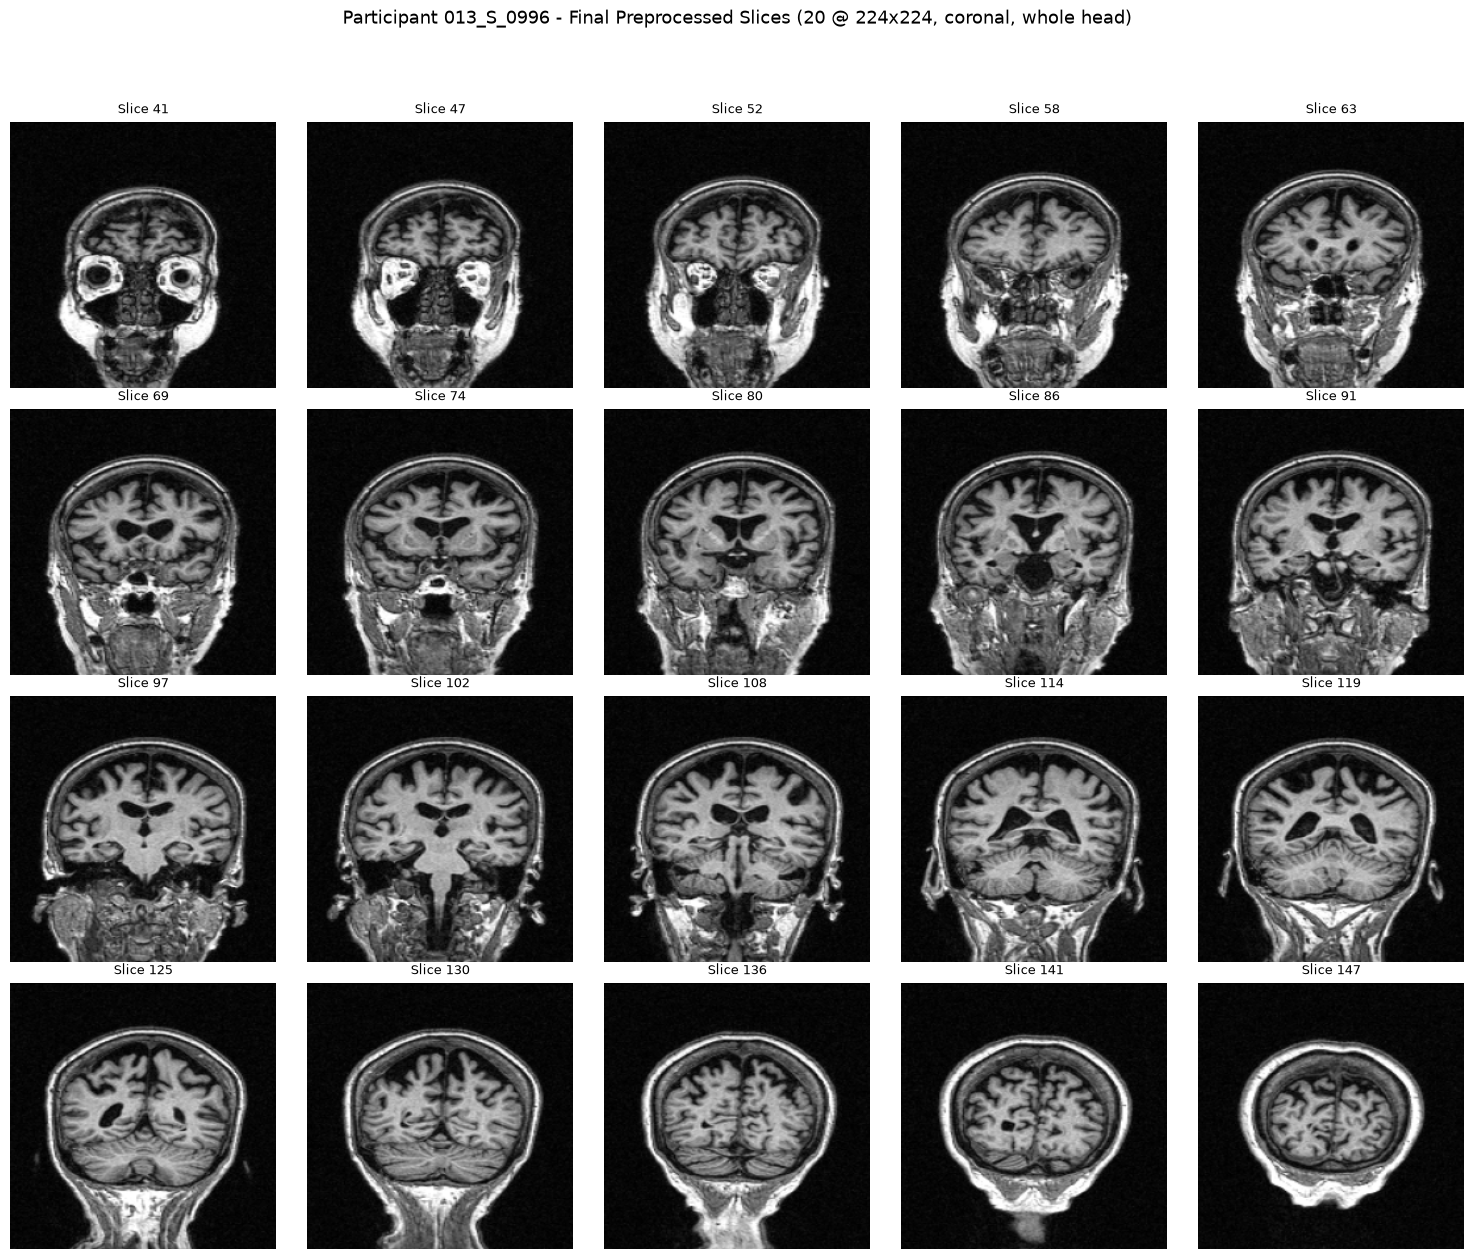

In [14]:
# ============================================================
# Resize the Selected Slices
# ============================================================

processed_slices = mri_utils.resize_slices(
    brain_volume, selected_indices, mri_utils.IMAGE_SIZE
)

print(f"Output shape    : {processed_slices.shape}")
print(f"Intensity range : {processed_slices.min():.3f} to "
      f"{processed_slices.max():.3f}")
print(f"Memory          : {processed_slices.nbytes / 1e6:.1f} MB "
      f"per participant")

# count the actual cohort instead of hardcoding
n_participants = len([d for d in MRI_FOLDER.iterdir() if d.is_dir()])

estimated_total = processed_slices.nbytes * n_participants / 1e9
print(f"Estimated total : {estimated_total:.2f} GB for "
      f"{n_participants} participants")

# ------------------------------------------------------------
# Display the full selected set
# ------------------------------------------------------------

n_show = min(20, len(processed_slices))
n_columns = 5
n_rows = int(np.ceil(n_show / n_columns))

fig, axes = plt.subplots(n_rows, n_columns, figsize=(15, 3.2 * n_rows))
axes = np.atleast_2d(axes).ravel()

for position in range(len(axes)):
    if position < n_show:
        axes[position].imshow(processed_slices[position], cmap="gray",
                              vmin=0, vmax=1)
        axes[position].set_title(f"Slice {selected_indices[position]}", fontsize=9)
    axes[position].axis("off")

plt.suptitle(
    f"Participant {participant_id} - Final Preprocessed Slices "
    f"({len(processed_slices)} @ {mri_utils.IMAGE_SIZE[0]}x"
    f"{mri_utils.IMAGE_SIZE[1]}, {PLANE}, whole head)",
    fontsize=13,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [17]:
# ============================================================
# Save Outputs and Parameters
# ============================================================

participant_output = PROCESSED_DATA / participant_id
participant_output.mkdir(parents=True, exist_ok=True)

np.save(participant_output / "slices.npy", processed_slices)
np.save(participant_output / "selected_indices.npy", selected_indices)
np.save(participant_output / "brain_content.npy", brain_content)

# ------------------------------------------------------------
# Record the preprocessing parameters
# ------------------------------------------------------------

parameters = {
    "participant_id": participant_id,
    "sequence": series["sequence"],
    "reoriented_volume_shape": list(volume.shape),
    "voxel_spacing_mm": [
        round(info["slice_spacing"], 4),
        round(info["row_spacing"], 4),
        round(info["column_spacing"], 4),
    ],
    "lower_percentile": mri_utils.LOWER_PERCENTILE,
    "upper_percentile": mri_utils.UPPER_PERCENTILE,
    "signal_threshold": mri_utils.SIGNAL_THRESHOLD,
    "brain_content_threshold": mri_utils.BRAIN_CONTENT_THRESHOLD,
    "n_slices_requested": mri_utils.N_SLICES_PER_PARTICIPANT,
    "n_slices_selected": int(len(selected_indices)),
    "selected_indices": [int(i) for i in selected_indices],
    "image_size": list(mri_utils.IMAGE_SIZE),
    "plane": PLANE,
    "skull_stripped": SKULL_STRIP,
    "brain_mask_fraction": round(float(mask_fraction), 4),
    "signal_retained_after_masking": round(float(retained), 4),
}

with open(participant_output / "parameters.json", "w") as handle:
    json.dump(parameters, handle, indent=2)

print(f"Saved to {participant_output}\n")
for file in sorted(participant_output.iterdir()):
    print(f"  {file.name:<24} {file.stat().st_size / 1024:>9.1f} KB")

print()
print(json.dumps(parameters, indent=2))

Saved to C:\Users\aimen\Documents\GitHub\MSc-Final-Project\processed\013_S_0996

  brain_content.npy              0.9 KB
  metadata.npy                   0.4 KB
  parameters.json                0.7 KB
  selected_indices.npy           0.3 KB
  slices.npy                  3920.1 KB
  volume.npy                 76800.1 KB

{
  "participant_id": "013_S_0996",
  "sequence": "MPRAGE",
  "reoriented_volume_shape": [
    192,
    192,
    160
  ],
  "voxel_spacing_mm": [
    1.2,
    1.25,
    1.25
  ],
  "lower_percentile": 1,
  "upper_percentile": 99,
  "signal_threshold": 0.05,
  "brain_content_threshold": 0.7,
  "n_slices_requested": 20,
  "n_slices_selected": 20,
  "selected_indices": [
    41,
    47,
    52,
    58,
    63,
    69,
    74,
    80,
    86,
    91,
    97,
    102,
    108,
    114,
    119,
    125,
    130,
    136,
    141,
    147
  ],
  "image_size": [
    224,
    224
  ],
  "plane": "coronal",
  "skull_stripped": false,
  "brain_mask_fraction": 0.1582,
  "signal_re

In [19]:
# ============================================================
# Validate the Full Pipeline Function
#
# Confirm that mri_utils.preprocess_participant() reproduces
# the step-by-step preprocessing result above. Notebook 4 uses
# this function across the cohort, so both paths should agree.
# ============================================================

pipeline_slices, pipeline_metadata = mri_utils.preprocess_participant(
    MRI_FOLDER / participant_id,
    n_slices=mri_utils.N_SLICES_PER_PARTICIPANT,
    skull_strip=SKULL_STRIP,
    plane=PLANE,
)

print("Step-by-step shape :", processed_slices.shape)
print("Pipeline shape     :", pipeline_slices.shape)

assert pipeline_slices.shape == processed_slices.shape, \
    "Pipeline output shape differs from the manual walkthrough"

max_difference = np.abs(pipeline_slices - processed_slices).max()

print(f"Maximum difference : {max_difference:.2e}")

assert max_difference < 1e-5, \
    "Pipeline output differs numerically from the manual walkthrough"


print()
print("The single-call pipeline reproduces the walkthrough exactly.")
print("The full preprocessing function is consistent with the")
print("step-by-step implementation and is ready for use in Notebook 4.")

Step-by-step shape : (20, 224, 224)
Pipeline shape     : (20, 224, 224)
Maximum difference : 0.00e+00

The single-call pipeline reproduces the walkthrough exactly.
The full preprocessing function is consistent with the
step-by-step implementation and is ready for use in Notebook 4.


In [20]:
# ============================================================
# Notebook 3 Summary
# ============================================================

# Cohort size is derived from the available MRI folders.
if "n_participants" not in globals():
    n_participants = len([
        folder for folder in MRI_FOLDER.iterdir()
        if folder.is_dir()
    ])

selected_count = len(selected_indices)

print("=" * 58)
print("              PREPROCESSING SUMMARY")
print("=" * 58)

print(f"Cohort                 : {n_participants} participants")
print(f"Example participant    : {participant_id}")
print(f"Reoriented volume      : {volume.shape}")
print(f"Output slices          : {processed_slices.shape}")

print()
print("Pipeline steps")
print("-" * 46)

print("  1. DICOM load and anatomical ordering")

print(
    f"  2. Percentile normalisation "
    f"({mri_utils.LOWER_PERCENTILE}-"
    f"{mri_utils.UPPER_PERCENTILE}%) to [0,1]"
)

print("  3. Brain extraction assessment (not applied)")
print(f"  4. Reorient to {PLANE}")

print(
    f"  5. Informative slice sampling "
    f"({selected_count} evenly spaced)"
)

print(
    f"  6. Resize to "
    f"{mri_utils.IMAGE_SIZE[0]}x{mri_utils.IMAGE_SIZE[1]}"
)

print()
print("Preprocessing configuration")
print("-" * 46)

print(
    f"  Analysis plane         : {PLANE}"
)

print(
    f"  Skull stripping        : "
    f"{'enabled' if SKULL_STRIP else 'disabled'}"
)

print(
    f"  Slices per participant : {selected_count}"
)

print(
    f"  Estimated dataset size : "
    f"{selected_count * n_participants:,} images"
)

print()
print("The same preprocessing configuration is used by the shared ")
print("pipeline function that will be applied across the cohort ")
print("in Notebook 4.")


print("=" * 58)

              PREPROCESSING SUMMARY
Cohort                 : 411 participants
Example participant    : 013_S_0996
Reoriented volume      : (192, 192, 160)
Output slices          : (20, 224, 224)

Pipeline steps
----------------------------------------------
  1. DICOM load and anatomical ordering
  2. Percentile normalisation (1-99%) to [0,1]
  3. Brain extraction assessment (not applied)
  4. Reorient to coronal
  5. Informative slice sampling (20 evenly spaced)
  6. Resize to 224x224

Preprocessing configuration
----------------------------------------------
  Analysis plane         : coronal
  Skull stripping        : disabled
  Slices per participant : 20
  Estimated dataset size : 8,220 images

The same preprocessing configuration is used by the shared 
pipeline function that will be applied across the cohort 
in Notebook 4.


### Next step

Notebook 4 applies the preprocessing pipeline across the full cohort and builds the
final train, validation and test datasets using a stratified participant-level
split. This preserves diagnostic-group representation while ensuring that data
from the same participant cannot appear in more than one dataset split.